In [1]:
import pandas as pd
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/dark_patterns.csv')

def clean_text(text):
    import re
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
print(df.shape)
df.head()

(2356, 5)


,page_id,text,label,Pattern Category,clean_text
0,1012,FLASH SALE | LIMITED TIME ONLY Shop Now,1,Urgency,flash sale limited time only shop now
1,158,Pillowcases & Shams,0,Not Dark Pattern,pillowcases shams
2,108,Write a review,0,Not Dark Pattern,write a review
3,1425,"To start your return, simply click on the foll...",0,Not Dark Pattern,to start your return simply click on the follo...
4,1658,newsletter signup (privacy policy),0,Not Dark Pattern,newsletter signup privacy policy


In [2]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training samples:", X_train_tfidf.shape[0])
print("Test samples:", X_test_tfidf.shape[0])
print("Features:", X_train_tfidf.shape[1])

Training samples: 1884
Test samples: 472
Features: 5000


In [4]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

y_pred = lr.predict(X_test_tfidf)
y_prob = lr.predict_proba(X_test_tfidf)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93       236
           1       0.96      0.89      0.93       236

    accuracy                           0.93       472
   macro avg       0.93      0.93      0.93       472
weighted avg       0.93      0.93      0.93       472

ROC-AUC Score: 0.9713


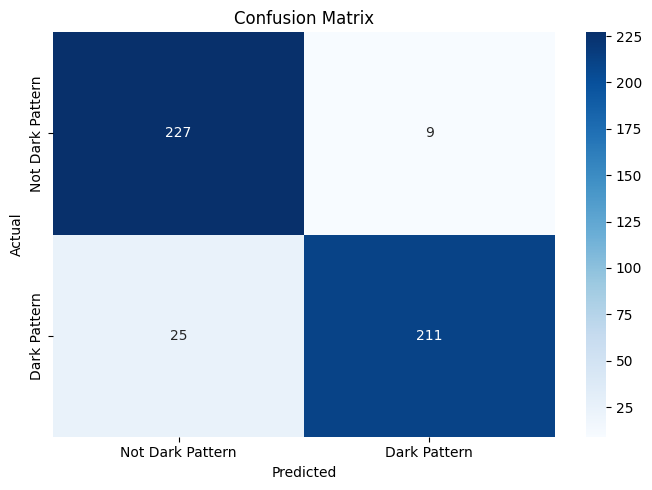

In [5]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Dark Pattern', 'Dark Pattern'],
            yticklabels=['Not Dark Pattern', 'Dark Pattern'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150)
plt.show()

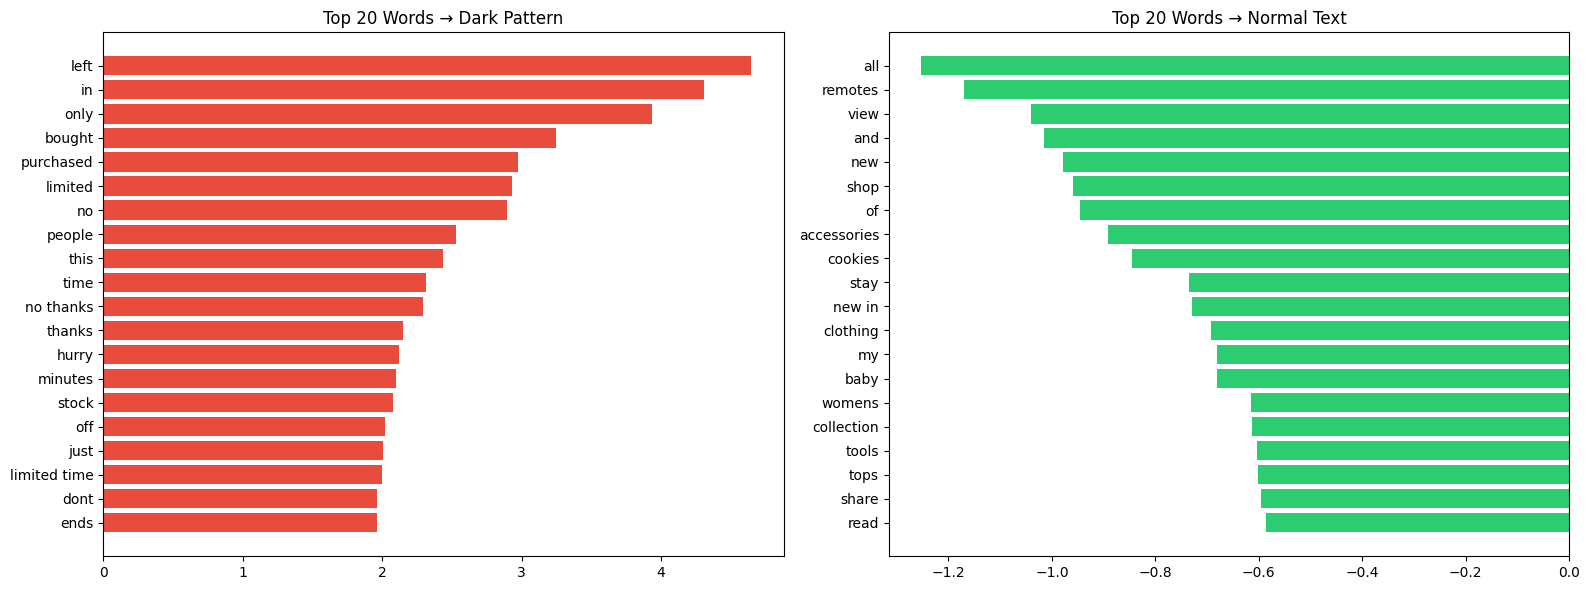

In [6]:
feature_names = tfidf.get_feature_names_out()
coefficients = lr.coef_[0]

top_positive_idx = coefficients.argsort()[-20:][::-1]
top_negative_idx = coefficients.argsort()[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# top dark pattern words
axes[0].barh([feature_names[i] for i in top_positive_idx],
             [coefficients[i] for i in top_positive_idx],
             color='#e74c3c')
axes[0].set_title('Top 20 Words → Dark Pattern')
axes[0].invert_yaxis()

# top normal words
axes[1].barh([feature_names[i] for i in top_negative_idx],
             [coefficients[i] for i in top_negative_idx],
             color='#2ecc71')
axes[1].set_title('Top 20 Words → Normal Text')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../data/top_features.png', dpi=150)
plt.show()

In [7]:
import joblib

joblib.dump(lr, '../models/logistic_regression.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')

print("Model saved.")
print("Vectorizer saved.")

Model saved.
Vectorizer saved.
